In [46]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt
import json

In [47]:
DATA_ROOT = r"E:\Education\4 course 2 semester\Diploma\panoptic_project\data\LaRS_fusion\semantic_deeplab3v+"

In [48]:
class LARSSemanticDataset(Dataset):
    def __init__(self, split, img_size=(640, 640)):
        self.img_dir = os.path.join(DATA_ROOT, split, "images")
        self.mask_dir = os.path.join(DATA_ROOT, split, "masks")
        self.images = sorted(os.listdir(self.img_dir))
        self.img_size = img_size
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]

        img_path = os.path.join(self.img_dir, name)
        base_name = os.path.splitext(name)[0]
        mask_path = os.path.join(self.mask_dir, base_name + ".png")

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Image not found: {img_path}")

        if mask is None:
            raise ValueError(f"Mask not found: {mask_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, self.img_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0

        image = (image - self.mean) / self.std

        image = torch.from_numpy(image).permute(2,0,1)
        mask = torch.from_numpy(mask).long()

        return image, mask

In [49]:
val_ds = LARSSemanticDataset("val")

val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=True, drop_last=True)

In [50]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=3
)

model.load_state_dict(torch.load(r"E:\Education\4 course 2 semester\Diploma\panoptic_project\runs\semantic_segmentation\deeplab_30\2\deeplab_lars_30.pth"))
model = model.cuda()

C:\Users\follo\AppData\Local\Temp\ipykernel_14124\561252665.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"E:\Education\4 course 2 se

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

cuda


DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [52]:
def compute_iou_per_class(model, dataloader, device, num_classes=3):
    model.eval()

    intersection = np.zeros(num_classes)
    union = np.zeros(num_classes)

    with torch.no_grad():
        for images, masks in tqdm(dataloader):
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            preds = torch.argmax(preds, dim=1)

            for cls in range(num_classes):
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)

                inter = (pred_cls & mask_cls).sum().item()
                u = (pred_cls | mask_cls).sum().item()

                intersection[cls] += inter
                union[cls] += u

    iou = intersection / (union + 1e-6)
    return iou

In [43]:
ious = compute_iou_per_class(model, val_loader, device)

class_names = ["water", "sky", "obstacle"]

for i, name in enumerate(class_names):
    print(f"{name}: IoU = {ious[i]:.4f}")

# 🔥 mIoU
miou = np.mean(ious)
print("\nmIoU:", miou)


# 🔥 Pixel Accuracy
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        preds = torch.argmax(preds, dim=1)

        correct += (preds == masks).sum().item()
        total += masks.numel()

pixel_acc = correct / total

print("Pixel Accuracy:", pixel_acc)

100%|██████████| 49/49 [00:25<00:00,  1.95it/s]


water: IoU = 0.9354
sky: IoU = 0.9731
obstacle: IoU = 0.9757

mIoU: 0.9614018983164602
Pixel Accuracy: 0.9811442433571329


In [53]:
COLORS = {
    0: (0, 0, 255),
    1: (135, 206, 235),
    2: (0, 255, 0)     
}

def visualize_prediction(model, dataset, device, idx=0):
    model.eval()

    image, mask = dataset[idx]

    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device))
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()
    

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
    image = image.detach().cpu()
    image = image * std + mean
    image = image.permute(1, 2, 0).numpy()
    image_np = np.clip(image, 0, 1)

    # создаём цветную маску
    color_mask = np.zeros_like(image_np)

    for cls, color in COLORS.items():
        color_mask[pred == cls] = np.array(color) / 255.0

    # overlay
    overlay = 0.6 * image_np + 0.4 * color_mask

    # plot
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image_np)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    gt_mask = np.zeros_like(image_np)
    for cls, color in COLORS.items():
        gt_mask[mask.numpy() == cls] = np.array(color) / 255.0
    plt.imshow(image_np)
    plt.imshow(gt_mask)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

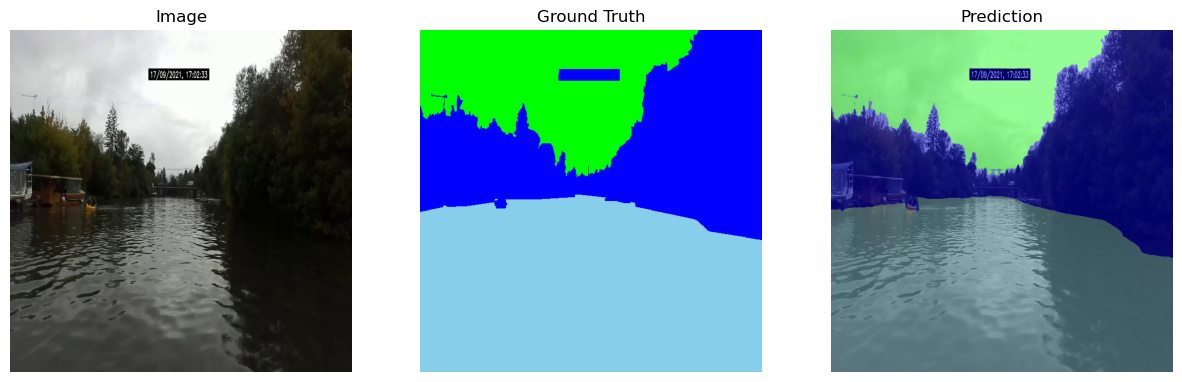

In [54]:
visualize_prediction(model, val_ds, device, idx=0)